In [6]:
import sys
import os
import numpy as np

# This should eventually be moved to an __init__.py file 
sys.path.insert(0, './functions/')
sys.path.insert(0, './data/')
import read_data as rd
import cost 
import ammortization
import replacement
import constants
import plotMACC
# import rev_alias

%matplotlib inline
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plant_data, cost_data, cf_data, age_data, emisisons_data, pv_cf_data, wind_cf_data = rd.read_data(os.getcwd())
plant_data = rd.clean_plant_data(plant_data)

In [3]:
cost_dict = cost_data.to_dict("dict")
cf_dict = dict(zip(cf_data.index, cf_data.capacity_factor.values))
emissions_dict = dict(zip(emisisons_data.index, emisisons_data.co2_lb_per_mmbtu.values*constants.lb_kg*constants.kg_tonne/constants.mmbtu_btu))

In [4]:
points = plant_data.loc[:, ["lat", "lon"]].values
pv_locs = pv_cf_data[["latitude", "longitude"]].values
wind_locs = wind_cf_data[["latitude", "longitude"]].values

pv_cfs = replacement.select_cf(points, pv_locs, pv_cf_data["capacity_factor"].values)
wind_cfs = replacement.select_cf(points, wind_locs, wind_cf_data["capacity_factor"].values)

hold_dict = cf_dict.copy()
hold_dict["Solar"] = pv_cfs
hold_dict["Wind"] = wind_cfs


In [7]:
plant_data["rep_fuel"], plant_data["metric"], plant_data["em_red"] = replacement.replacement_iteration(plant_data["primary_fuel"].map(cost_dict["variable_om_per_mwh"]),
                                  plant_data["primary_fuel"].map(cost_dict["fixed_om_per_kw_year"]),
                                  plant_data["primary_fuel"].map(cost_dict["fuel_price_per_btu"]),
                                  0, # plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]),
                                  0.06,
                                  30,
                                  plant_data["generation"],
                                  plant_data["capacity"],
                                  plant_data["fuel_consumption"],
                                 2017-plant_data["commissioning_year"],
                                 plant_data["emissions"],
                                 cf_dict,
                                 # hold_dict,
                                 cost_dict,
                                 emissions_dict,
                                 metric = 1)
cap_val = 2e2
plant_data1 = plant_data[plant_data.metric.between(-cap_val, cap_val) & (plant_data["em_red"] > 1)]
plant_data1.sort_values("metric", inplace = True)
plant_data1["cum_red"] = np.cumsum(plant_data1["em_red"])
plant_data1["cum_red_prev"] = np.cumsum(plant_data1["em_red"])-plant_data1["em_red"]
plant_data1["ori_rep"] = plant_data1["primary_fuel"]+"_"+plant_data1["rep_fuel"]


C:\Users\jonat\AppData\Local\Temp/ipykernel_5472/2475399923.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\jonat\AppData\Local\Temp/ipykernel_5472/2475399923.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\jonat\AppData\Local\Temp/ipykernel_5472/2475399923.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:719: PlotnineWarning: Saving 6.4 x 4.8 in image.
C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:722: PlotnineWarning: Filename: MACC_plot.png


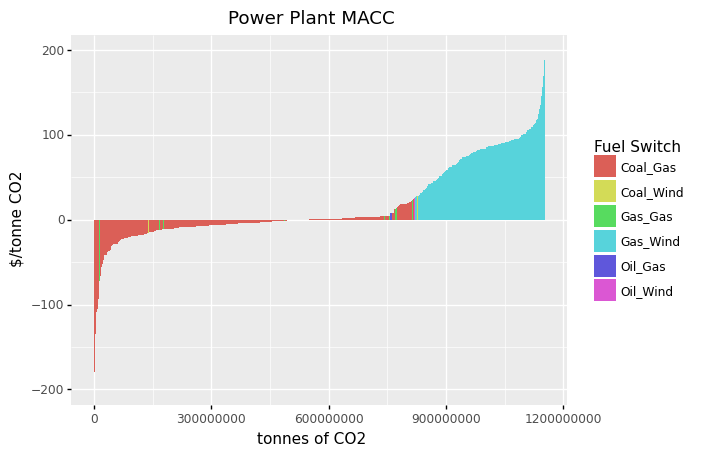

<ggplot: (116769534925)>

In [8]:
plotMACC.plotMACC(plant_data1)